In [4]:
#importing libraries
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
#load the dataset
df=pd.read_csv('spotify-tracks-dataset-detailed.csv')

In [6]:
#shape of the dataset
df.shape

(114000, 20)

In [7]:
#features of the dataset
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [9]:
#remove null values
df.dropna(inplace=True)

In [10]:
df.drop('track_id',axis=1, inplace=True)

In [11]:
df.head(10)

,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,0.4810,6,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,0.1470,2,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,0.4440,11,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,0.4140,0,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,0.6320,1,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


In [12]:
#identifying duplicates
print(df[['track_name','artists']].duplicated().sum())

32656


In [13]:
#removing duplicates
df.drop_duplicates(subset=['track_name','artists'], inplace=True)

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 81343 entries, 0 to 113999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artists           81343 non-null  str    
 1   album_name        81343 non-null  str    
 2   track_name        81343 non-null  str    
 3   popularity        81343 non-null  int64  
 4   duration_ms       81343 non-null  int64  
 5   explicit          81343 non-null  bool   
 6   danceability      81343 non-null  float64
 7   energy            81343 non-null  float64
 8   key               81343 non-null  int64  
 9   loudness          81343 non-null  float64
 10  mode              81343 non-null  int64  
 11  speechiness       81343 non-null  float64
 12  acousticness      81343 non-null  float64
 13  instrumentalness  81343 non-null  float64
 14  liveness          81343 non-null  float64
 15  valence           81343 non-null  float64
 16  tempo             81343 non-null  float64
 17  time_sig

EDA

In [15]:
#total tracks
df['track_name'].nunique()

73608

In [16]:
#total artists
df['artists'].nunique()

31437

In [17]:
#total genres
df['track_genre'].nunique()

113

In [18]:
#most common genre
df['track_genre'].value_counts().head(1)

track_genre
study    996
Name: count, dtype: int64

In [19]:
#most common artist
df['artists'].value_counts().head(1)

artists
George Jones    215
Name: count, dtype: int64

The dataset contains approximately 80,000 unique songs across 113 genres. The diversity of genres makes it suitable for clustering-based music recommendation.

In [20]:
#most popular songs
df.sort_values('popularity',ascending=False)[['track_name','popularity']].head(1)

,track_name,popularity
20001,Unholy (feat. Kim Petras),100


In [21]:
#most popular artist
df.sort_values('popularity',ascending=False)[['artists','popularity']].head(1)

,artists,popularity
20001,Sam Smith;Kim Petras,100


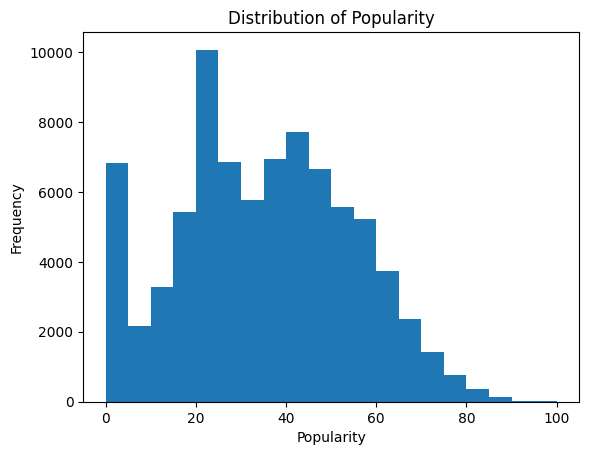

In [22]:
#Distribution of popularity
plt.hist(df['popularity'], bins=20)
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()

The dataset is dominated by moderately popular songs rather than viral hits.

Only a small fraction of tracks achieve very high popularity, which is expected because blockbuster songs represent a tiny portion of all music available on Spotify.

Listener attention is concentrated on a subset of songs, while most tracks remain moderately popular.

The dataset includes niche, regional, independent, or newly released tracks in addition to mainstream music.

The dataset has right skewness.

In [23]:
#feature selection
audio_features=['danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo']

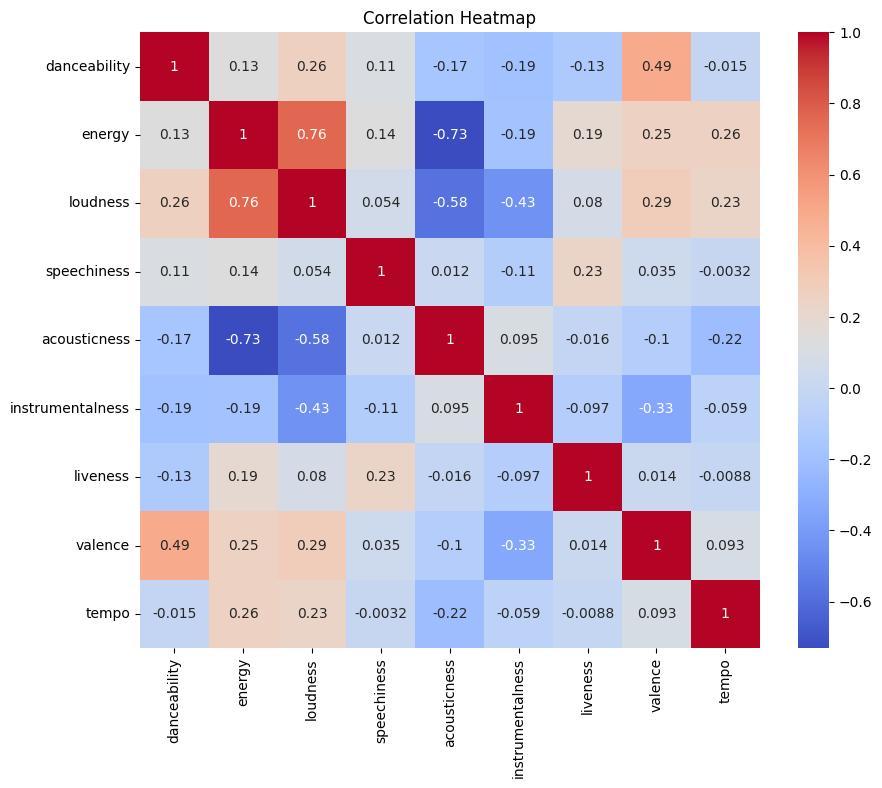

In [24]:
#heatmap
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Correlation analysis revealed a strong positive relationship between Energy and Loudness (0.76), indicating that energetic songs tend to be louder. 

Acousticness showed strong negative correlations with Energy (-0.73) and Loudness (-0.58), suggesting that acoustic tracks are generally calmer and quieter. 

Danceability and Valence exhibited a moderate positive correlation (0.49), implying that songs with a more positive mood are often more danceable. 

Features such as Tempo and Speechiness showed weak correlations with most variables, indicating that they provide unique information useful for clustering.

In [25]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

scaled_features= scaler.fit_transform(df[audio_features])

In [26]:
print(scaled_features[:5])

[[ 0.65669378 -0.67284939  0.34835288  0.46307261 -0.87500549 -0.55710929
   0.69741576  0.95573562 -1.13604934]
 [-0.78356805 -1.81343427 -1.62892644 -0.10883058  1.74825451 -0.55709557
  -0.598793   -0.74521932 -1.48216305]
 [-0.68229964 -1.06722111 -0.21491441 -0.28546036 -0.35200075 -0.55711234
  -0.51809517 -1.30334516 -1.52056481]
 [-1.64997556 -2.22481811 -1.87021899 -0.45180102  1.69236536 -0.55689913
  -0.44244097 -1.21601934  1.97801147]
 [ 0.33038446 -0.7424444  -0.2049234  -0.31204056  0.40985655 -0.55711234
  -0.69008241 -1.12489676 -0.07288151]]


In [27]:
#to find optimal k
from sklearn.cluster import KMeans

wcss=[]

for k in range(1,16):
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

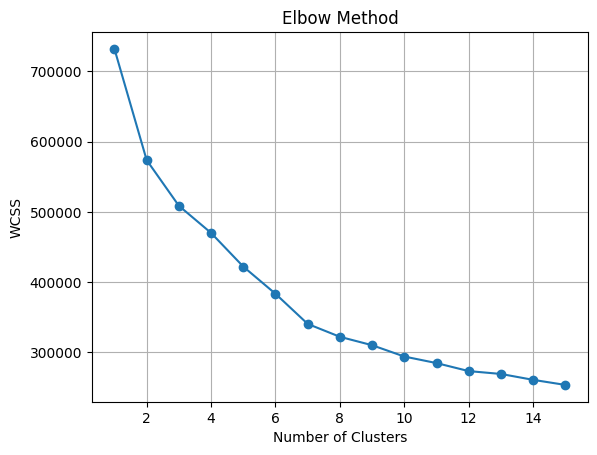

In [28]:
#plot elbow curve
plt.plot(range(1,16),wcss, marker='o')
plt.title('Elbow Method')
plt.grid()
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

In [29]:
#find bend point
from kneed import KneeLocator 

knee= KneeLocator(range(1,16), wcss, curve='convex', direction='decreasing')
optimal_k= knee.knee
print(f'Optimal number of clusters: {optimal_k}')

Optimal number of clusters: 7


In [30]:
#silhouette score
from sklearn.metrics import silhouette_score

silhouette_scores=[]

for k in range(2,16):
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    score= silhouette_score(scaled_features, kmeans.labels_)
    silhouette_scores.append(score)

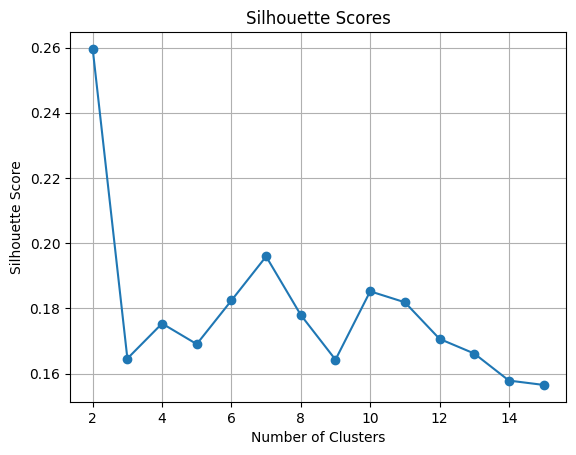

In [31]:
#plot silhouette scores
plt.plot(range(2,16), silhouette_scores, marker='o')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

In [32]:
#finding optimal k from silhouette scores
optimal_k_silhouette= range(2,16)[silhouette_scores.index(max(silhouette_scores))]
print(f'Optimal number of clusters based on silhouette score: {optimal_k_silhouette}')

Optimal number of clusters based on silhouette score: 2


In [33]:
#training kmeans model with optimal k
kmeans= KMeans(n_clusters= optimal_k, random_state=42)

df['cluster']= kmeans.fit_predict(scaled_features)

In [34]:
df['cluster'].value_counts()

cluster
0    23975
3    18405
1    16146
2     9736
6     6261
4     5797
5     1023
Name: count, dtype: int64

In [35]:
df.groupby('cluster')[audio_features].mean()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.704924,0.714854,-6.640868,0.098227,0.227665,0.022250,0.165454,0.703598,118.762739
1,0.529796,0.377008,-10.665582,0.054946,0.683744,0.038808,0.160111,0.387816,113.424618
2,0.583036,0.740793,-8.482418,0.071985,0.113124,0.797147,0.169433,0.343861,127.011257
3,0.471007,0.820990,-5.335395,0.086611,0.073017,0.039075,0.196661,0.368477,139.263848
4,0.515084,0.751757,-7.167302,0.088407,0.295297,0.081223,0.749974,0.497125,123.145593
5,0.571210,0.678880,-11.187322,0.849792,0.750825,0.006388,0.673220,0.437397,100.508751
6,0.339071,0.168338,-21.379731,0.051112,0.861336,0.784079,0.162204,0.174883,102.301317


In [36]:
#cluster naming
cluster_names = {
    0: "🔥 High Energy Dance Tracks",
    1: "🎸 Acoustic & Emotional Songs",
    2: "🎹 Instrumental & Ambient Music",
    3: "⚡ Workout & Party Songs",
    4: "🎤 Live Performance Tracks",
    5: "🎙 Rap & Spoken Word",
    6: "🌙 Chill & Relaxing Music"
}

In [37]:
#scaled features dataframe
scaled_df= pd.DataFrame(scaled_features, columns= audio_features, index=df.index)

scaled_df['track_name']= df['track_name']
scaled_df['artists']=df['artists']
scaled_df['cluster']= df['cluster']

In [38]:
#recommendation function
from sklearn.metrics.pairwise import cosine_similarity

def recommend(song_name, artist_name=None, top_n=5):
    
    temp = scaled_df[
        scaled_df['track_name'].str.lower() == song_name.lower()
    ]
    
    if artist_name:
        temp = temp[
            temp['artists'].str.lower() == artist_name.lower()
        ]
    
    if len(temp) == 0:
        return "Song not found"
    
    selected_song = temp.iloc[0]
    
    cluster_id = selected_song['cluster']
    
    cluster_songs = scaled_df[
        scaled_df['cluster'] == cluster_id
    ].copy()
    
    song_vector = selected_song[audio_features].values.reshape(1,-1)
    
    similarities = cosine_similarity(
        song_vector,
        cluster_songs[audio_features]
    )[0]
    
    cluster_songs['similarity'] = similarities
    
    cluster_songs = cluster_songs[
        cluster_songs.index != selected_song.name
    ]
    
    return cluster_songs.sort_values(
        by='similarity',
        ascending=False
    )[
        ['track_name','artists','similarity']
    ].head(top_n)

In [39]:
recommend('The night we met', 'Lord Huron')

,track_name,artists,similarity
105688,Forever to Stay,Justnormal,0.959269
12186,約定,Faye Wong,0.953230
111737,Recipe for Disaster - Acoustic,Morcheeba,0.932146
98691,Your Song / Someone's Waiting for You,Lea Salonga,0.926144
98383,The Journey To The Heaviside Layer,"Andrew Lloyd Webber;""Cats"" 1983 Broadway Cast",0.924799


In [40]:
#saving the final dataset
scaled_df.to_csv('spotify_tracks_with_clusters.csv', index=False)

In [41]:
#saving the model
import joblib
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']